# Federated Fine-Tuning of Gemma-2B with LoRA (4-bit) across 3 Organizations

This notebook simulates the federated learning pipeline described below, entirely on a single machine (one Jupyter kernel simulating 3 clients + 1 server):

```
[Org A: food recipes]   [Org B: healthcare]   [Org C: python introduction]
        |                       |                          |
   Local fine-tune         Local fine-tune            Local fine-tune
        |                       |                          |
        +-----------> Aggregator (FedAvg) <-----------------+
                            |
                     Global Model v1
                            |
              (Optional centralized fine-tune)
                            |
                     Global Model v1.5
                            |
              Distributed back to orgs --> repeat rounds
                            |
                     Global Model v2
                            |
        Each org locally fine-tunes their own copy for
        personalization (Global + Local = Personalized Model)
```

**Stack**
- **Base model:** `google/gemma-2b` (4-bit quantized via `bitsandbytes`)
- **Fine-tuning:** LoRA, rank = 3, via `peft`
- **Federated logic:** manual FedAvg over LoRA adapter weights (no external FL server needed — runs in-process, which is the standard way to simulate FL for LLM fine-tuning experiments). Flower (`flwr`) is also installed/shown as the "real" alternative for going multi-machine, with notes on how to port this code to it.
- **Data:** real Kaggle datasets, loaded directly via `kagglehub`, one per org:
  - **Org A (food recipes):** `irkaal/foodcom-recipes-and-reviews`
  - **Org B (healthcare):** `pythonafroz/medquad-medical-question-answer-for-ai-research`
  - **Org C (python introduction):** `thedevastator/python-code-instruction-dataset`

**What this notebook does, step by step**
1. Install/import libraries
2. Authenticate Kaggle + Hugging Face, load 4-bit Gemma-2B + LoRA(r=3)
3. Download & preprocess the 3 datasets into instruction-style text for each "org"
4. Define a `Client` class (local training) and FedAvg aggregation over LoRA weights only
5. Run federated rounds → Global Model v1
6. (Optional) centralized fine-tune of the global model on a small public mix → Global Model v1.5
7. Repeat federated rounds → Global Model v2
8. Each org personalizes: Global v2 + local LoRA fine-tune = Personalized Model
9. Quick qualitative evaluation per org

> **Hardware note:** Gemma-2B in 4-bit + LoRA(r=3) fits comfortably on a single 16GB GPU (e.g. Colab T4/L4, Kaggle P100/T4). CPU-only will work but will be very slow — reduce `MAX_STEPS` and dataset sizes if so.


## 1. Install dependencies

In [1]:
# Core libs: transformers/peft/bitsandbytes/accelerate for the model + LoRA + 4-bit
# kagglehub to pull datasets directly by handle (no manual download/upload needed)
# flwr included only for reference/optional real-FL extension (see note at bottom of notebook)
!pip install -q -U transformers accelerate peft bitsandbytes datasets kagglehub trl sentencepiece scikit-learn
!pip install -q -U flwr


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.4/842.4 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 974.5/974.5 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/

In [2]:
import os, json, copy, random, gc, time
from dataclasses import dataclass, field
from typing import List, Dict, Optional

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    get_linear_schedule_with_warmup,
)
from peft import (
    LoraConfig,
    get_peft_model,
    get_peft_model_state_dict,
    set_peft_model_state_dict,
    PeftModel,
    prepare_model_for_kbit_training,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: no GPU detected. 4-bit quantization requires a CUDA GPU (bitsandbytes). "
          "This notebook will likely fail to load the model in 4-bit on CPU-only runtimes. "
          "Use a Colab/Kaggle GPU runtime (T4/L4/P100 or better).")


Device: cuda


## 2. Global configuration

In [3]:
@dataclass
class Config:
    # --- model ---
    base_model_id: str = "google/gemma-2b"   # use "google/gemma-2b-it" for an instruction-tuned start point
    lora_r: int = 3                          # rank requested
    lora_alpha: int = 8                      # ~2-3x rank is a common heuristic
    lora_dropout: float = 0.05
    lora_target_modules: tuple = ("q_proj", "k_proj", "v_proj", "o_proj")

    # --- quantization ---
    load_in_4bit: bool = True
    bnb_4bit_quant_type: str = "nf4"
    bnb_4bit_compute_dtype: torch.dtype = torch.bfloat16
    bnb_4bit_use_double_quant: bool = True

    # --- data ---
    max_seq_len: int = 256
    samples_per_org: int = 300     # subsample each org's dataset for a fast demo; raise for real training
    val_samples_per_org: int = 30

    # --- training (local client rounds) ---
    local_epochs: int = 1
    local_batch_size: int = 2
    grad_accum_steps: int = 4
    lr: float = 2e-4
    max_steps_per_round: int = 60  # cap steps per client per round so demo runs fast; set None for full epoch

    # --- federated ---
    num_rounds_phase1: int = 2     # rounds before centralized fine-tune (-> Global v1)
    num_rounds_phase2: int = 2     # rounds after centralized fine-tune (-> Global v2)
    fedavg_weighting: str = "uniform"  # "uniform" or "by_dataset_size"

    # --- misc ---
    output_dir: str = "./fl_outputs"
    hf_token: Optional[str] = None  # set if google/gemma-2b requires auth and you have a token

CFG = Config()
os.makedirs(CFG.output_dir, exist_ok=True)
CFG


Config(base_model_id='google/gemma-2b', lora_r=3, lora_alpha=8, lora_dropout=0.05, lora_target_modules=('q_proj', 'k_proj', 'v_proj', 'o_proj'), load_in_4bit=True, bnb_4bit_quant_type='nf4', bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True, max_seq_len=256, samples_per_org=300, val_samples_per_org=30, local_epochs=1, local_batch_size=2, grad_accum_steps=4, lr=0.0002, max_steps_per_round=60, num_rounds_phase1=2, num_rounds_phase2=2, fedavg_weighting='uniform', output_dir='./fl_outputs', hf_token=None)

**Notes on the hyperparameters above**
- `lora_r=3` is intentionally tiny (as requested) -- fine for a demo / proof-of-concept, but in practice rank 3 is very low capacity for a 2B model; bump to 8-16 for real quality.
- `max_steps_per_round` and `samples_per_org` are deliberately small so the whole pipeline (3 clients x multiple rounds) finishes in a reasonable time on a single GPU. Increase them once you've confirmed the pipeline runs end-to-end.
- Gemma weights are gated on Hugging Face. Run `huggingface-cli login` or set `CFG.hf_token`, and make sure you've accepted the license at https://huggingface.co/google/gemma-2b.


In [4]:
CFG.hf_token = "hf_"

In [5]:
# --- Authenticate Hugging Face (for gated Gemma weights) ---
# Option A: interactive login (uncomment)
# from huggingface_hub import notebook_login
# notebook_login()

# Option B: token via env var / config
from huggingface_hub import login as hf_login
if CFG.hf_token:
    hf_login(token=CFG.hf_token)
elif os.environ.get("HF_TOKEN"):
    hf_login(token=os.environ["HF_TOKEN"])
else:
    print("No HF token set yet. If model loading fails with a 401/gated-repo error, "
          "run notebook_login() above or set os.environ['HF_TOKEN'] = '<your_token>'.")


In [ ]:
from huggingface_hub import HfApi

api = HfApi()
print(api.model_info("google/gemma-2b"))

ModelInfo(id='google/gemma-2b', author='google', base_models=None, card_data={'base_model': None, 'datasets': None, 'eval_results': None, 'language': None, 'library_name': 'transformers', 'license': 'gemma', 'license_name': None, 'license_link': None, 'metrics': None, 'model_name': None, 'pipeline_tag': None, 'tags': None, 'new_version': 'google/gemma-2-2b', 'extra_gated_heading': 'Access Gemma on Hugging Face', 'extra_gated_prompt': 'To access Gemma on Hugging Face, you’re required to review and agree to Google’s usage license. To do this, please ensure you’re logged-in to Hugging Face and click below. Requests are processed immediately.', 'extra_gated_button_content': 'Acknowledge license'}, children_model_count=None, config={'architectures': ['GemmaForCausalLM'], 'model_type': 'gemma', 'tokenizer_config': {'bos_token': '<bos>', 'eos_token': '<eos>', 'pad_token': '<pad>', 'unk_token': '<unk>', 'use_default_system_prompt': False}}, created_at=datetime.datetime(2024, 2, 8, 8, 11, 26, t

In [ ]:
import bitsandbytes as bnb
print(bnb.__version__)

0.49.2


In [6]:
# --- Authenticate Kaggle (for kagglehub dataset downloads) ---
# kagglehub looks for credentials in (in order): kagglehub.login(), ~/.kaggle/kaggle.json,
# or the KAGGLE_USERNAME / KAGGLE_KEY environment variables.
import kagglehub

# Option A: interactive (uncomment if running locally/Colab and you don't have kaggle.json set up)
# kagglehub.login()

# Option B: if KAGGLE_USERNAME / KAGGLE_KEY are already set as env vars (e.g. Kaggle Notebooks
# do this automatically), kagglehub will pick them up with no extra code needed.
print("Kaggle auth ready (kagglehub will prompt interactively if no credentials are found).")


Kaggle auth ready (kagglehub will prompt interactively if no credentials are found).


## 3. Load Gemma-2B in 4-bit and attach a LoRA adapter (rank 3)

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=CFG.load_in_4bit,
    bnb_4bit_quant_type=CFG.bnb_4bit_quant_type,
    bnb_4bit_compute_dtype=CFG.bnb_4bit_compute_dtype,
    bnb_4bit_use_double_quant=CFG.bnb_4bit_use_double_quant,
)

tokenizer = AutoTokenizer.from_pretrained(CFG.base_model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    CFG.base_model_id,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=CFG.bnb_4bit_compute_dtype,
)

# Required prep step for k-bit (4-bit/8-bit) training: casts norms to fp32,
# enables gradient checkpointing, makes input embeddings require grad, etc.
base_model = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=CFG.lora_r,
    lora_alpha=CFG.lora_alpha,
    lora_dropout=CFG.lora_dropout,
    target_modules=list(CFG.lora_target_modules),
    bias="none",
    task_type="CAUSAL_LM",
)

global_model = get_peft_model(base_model, lora_config)
global_model.print_trainable_parameters()


config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

trainable params: 691,200 || all params: 2,506,863,616 || trainable%: 0.0276


This `global_model` is the **Global Model v0** — the starting point before any federated rounds.
Because only the LoRA adapter is trainable (the 4-bit base weights are frozen), federated
aggregation only ever needs to communicate the small LoRA adapter state dict, not the full
2B-parameter model. This is the key trick that makes federated LLM fine-tuning practical.


## 4. Load each org's dataset directly from Kaggle (`kagglehub`)

Each org gets a real, public Kaggle dataset, reshaped into simple instruction-style text:

| Org | Domain | Kaggle dataset |
|---|---|---|
| A | Food recipes | `irkaal/foodcom-recipes-and-reviews` |
| B | Healthcare | `pythonafroz/medquad-medical-question-answer-for-ai-research` |
| C | Python introduction | `thedevastator/python-code-instruction-dataset` |

`kagglehub.dataset_download(handle)` downloads (and caches) the dataset and returns a local folder
path — no manual zip download/upload needed. We then load whichever CSV file is in that folder.


In [8]:
def find_csv(folder, prefer_substrings=None):
    """Find a CSV file in a downloaded kagglehub dataset folder.
    If prefer_substrings is given, prefer filenames containing one of those substrings."""
    csvs = []
    for root, _, files in os.walk(folder):
        for fn in files:
            if fn.lower().endswith(".csv"):
                csvs.append(os.path.join(root, fn))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found under {folder}")
    if prefer_substrings:
        for sub in prefer_substrings:
            for c in csvs:
                if sub.lower() in os.path.basename(c).lower():
                    return c
    # fallback: biggest CSV (usually the main data file, not a small metadata file)
    return max(csvs, key=os.path.getsize)


def build_prompt(instruction, response, input_text=None):
    """Simple, consistent instruction-tuning template shared across all 3 orgs."""
    if input_text and str(input_text).strip():
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Input:\n{input_text}\n\n"
            f"### Response:\n{response}"
        )
    else:
        prompt = (
            f"### Instruction:\n{instruction}\n\n"
            f"### Response:\n{response}"
        )
    return prompt


### 4a. Org A -- Food recipes (`irkaal/foodcom-recipes-and-reviews`)

In [9]:
path_a = kagglehub.dataset_download("irkaal/foodcom-recipes-and-reviews")
print("Org A dataset folder:", path_a)
csv_a = find_csv(path_a, prefer_substrings=["recipes"])
print("Using file:", csv_a)

df_a_raw = pd.read_csv(csv_a)
print(df_a_raw.shape)
df_a_raw.head(2)


100%|██████████| 723M/723M [00:11<00:00, 64.9MB/s]

Extracting files...


Org A dataset folder: /root/.cache/kagglehub/datasets/irkaal/foodcom-recipes-and-reviews/versions/2
Using file: /root/.cache/kagglehub/datasets/irkaal/foodcom-recipes-and-reviews/versions/2/recipes.csv
(522517, 28)


,RecipeId,Name,AuthorId,AuthorName,CookTime,PrepTime,TotalTime,DatePublished,Description,Images,...,SaturatedFatContent,CholesterolContent,SodiumContent,CarbohydrateContent,FiberContent,SugarContent,ProteinContent,RecipeServings,RecipeYield,RecipeInstructions
0,38,Low-Fat Berry Blue Frozen Dessert,1533,Dancer,PT24H,PT45M,PT24H45M,1999-08-09T21:46:00Z,Make and share this Low-Fat Berry Blue Frozen ...,"c(""https://img.sndimg.com/food/image/upload/w_...",...,1.3,8.0,29.8,37.1,3.6,30.2,3.2,4.0,NaN,"c(""Toss 2 cups berries with sugar."", ""Let stan..."
1,39,Biryani,1567,elly9812,PT25M,PT4H,PT4H25M,1999-08-29T13:12:00Z,Make and share this Biryani recipe from Food.com.,"c(""https://img.sndimg.com/food/image/upload/w_...",...,16.6,372.8,368.4,84.4,9.0,20.4,63.4,6.0,NaN,"c(""Soak saffron in warm milk for 5 minutes and..."


In [10]:
def preprocess_org_a(df):
    """Food.com recipes -> 'how do I make X' style instructions.

    Expected columns (per the Food.com - Recipes and Reviews Kaggle dataset card):
    Name, RecipeIngredientParts, RecipeInstructions, among others.
    We defensively look up columns by fuzzy name in case of minor schema differences.
    """
    cols = {c.lower(): c for c in df.columns}

    def col(*candidates):
        for cand in candidates:
            for lc, orig in cols.items():
                if cand in lc:
                    return orig
        return None

    name_col = col("name")
    ingr_col = col("ingredientparts", "ingredients")
    instr_col = col("instructions")

    records = []
    for _, row in df.iterrows():
        name = row.get(name_col, None)
        instructions = row.get(instr_col, None)
        ingredients = row.get(ingr_col, None)
        if not isinstance(name, str) or not isinstance(instructions, str):
            continue
        if len(instructions.strip()) < 20:
            continue

        # Ingredients/instructions are often stored as R-style "c(...)" strings or
        # Python-list-like strings; do light cleanup without needing a strict parser.
        def clean_list_str(s):
            if not isinstance(s, str):
                return ""
            s = s.replace("c(", "").replace(")", "")
            s = s.replace('"', "").replace("'", "")
            return ", ".join([p.strip() for p in s.split(",") if p.strip()])

        ingr_clean = clean_list_str(ingredients) if isinstance(ingredients, str) else ""
        instr_clean = clean_list_str(instructions) if isinstance(instructions, str) else instructions

        instruction = f"Give me a recipe for {name}."
        input_text = f"Ingredients: {ingr_clean}" if ingr_clean else None
        response = instr_clean
        records.append({"instruction": instruction, "input": input_text, "response": response})
    return pd.DataFrame(records)

df_a = preprocess_org_a(df_a_raw)
print("Org A usable examples:", len(df_a))
df_a.head(2)


Org A usable examples: 522224


,instruction,input,response
0,Give me a recipe for Low-Fat Berry Blue Frozen...,"Ingredients: blueberries, granulated sugar, va...","Toss 2 cups berries with sugar., Let stand for..."
1,Give me a recipe for Biryani.,"Ingredients: saffron, milk, hot green chili pe...",Soak saffron in warm milk for 5 minutes and pu...


### 4b. Org B -- Healthcare Q&A (`pythonafroz/medquad-medical-question-answer-for-ai-research`)

In [11]:
path_b = kagglehub.dataset_download("pythonafroz/medquad-medical-question-answer-for-ai-research")
print("Org B dataset folder:", path_b)
csv_b = find_csv(path_b, prefer_substrings=["medquad", "medical"])
print("Using file:", csv_b)

df_b_raw = pd.read_csv(csv_b)
print(df_b_raw.shape)
df_b_raw.head(2)


100%|██████████| 4.95M/4.95M [00:00<00:00, 84.8MB/s]

Extracting files...
Org B dataset folder: /root/.cache/kagglehub/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/versions/1
Using file: /root/.cache/kagglehub/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/versions/1/medquad.csv


(16412, 4)


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma


In [12]:
def preprocess_org_b(df):
    """MedQuAD -> medical question/answer instructions.

    Expected columns: 'question' and 'answer' (sometimes 'qtype'/'focus_area' too).
    """
    cols = {c.lower(): c for c in df.columns}

    def col(*candidates):
        for cand in candidates:
            for lc, orig in cols.items():
                if cand == lc or cand in lc:
                    return orig
        return None

    q_col = col("question")
    a_col = col("answer")

    records = []
    for _, row in df.iterrows():
        q = row.get(q_col, None)
        a = row.get(a_col, None)
        if not isinstance(q, str) or not isinstance(a, str):
            continue
        if len(a.strip()) < 20:
            continue
        records.append({"instruction": q.strip(), "input": None, "response": a.strip()})
    return pd.DataFrame(records)

df_b = preprocess_org_b(df_b_raw)
print("Org B usable examples:", len(df_b))
df_b.head(2)


Org B usable examples: 16406


,instruction,input,response
0,What is (are) Glaucoma ?,None,Glaucoma is a group of diseases that can damag...
1,What causes Glaucoma ?,None,"Nearly 2.7 million people have glaucoma, a lea..."


### 4c. Org C -- Python introduction (`thedevastator/python-code-instruction-dataset`)

In [13]:
path_c = kagglehub.dataset_download("thedevastator/python-code-instruction-dataset")
print("Org C dataset folder:", path_c)
csv_c = find_csv(path_c, prefer_substrings=["train", "python"])
print("Using file:", csv_c)

df_c_raw = pd.read_csv(csv_c)
print(df_c_raw.shape)
df_c_raw.head(2)


100%|██████████| 3.88M/3.88M [00:00<00:00, 64.3MB/s]

Extracting files...


Org C dataset folder: /root/.cache/kagglehub/datasets/thedevastator/python-code-instruction-dataset/versions/2
Using file: /root/.cache/kagglehub/datasets/thedevastator/python-code-instruction-dataset/versions/2/train.csv
(18612, 4)


,instruction,input,output,prompt
0,Create a function to calculate the sum of a se...,"[1, 2, 3, 4, 5]",# Python code\ndef sum_sequence(sequence):\n ...,Below is an instruction that describes a task....
1,Generate a Python code for crawling a website ...,website: www.example.com \ndata to crawl: phon...,import requests\nimport re\n\ndef crawl_websit...,Below is an instruction that describes a task....


In [14]:
def preprocess_org_c(df):
    """Python Code Instruction dataset -> already instruction/input/output shaped.

    Expected columns: 'instruction', 'input', 'output' (and sometimes a combined 'prompt').
    """
    cols = {c.lower(): c for c in df.columns}

    def col(*candidates):
        for cand in candidates:
            for lc, orig in cols.items():
                if cand == lc or cand in lc:
                    return orig
        return None

    instr_col = col("instruction")
    input_col = col("input")
    out_col = col("output", "response")

    records = []
    for _, row in df.iterrows():
        instr = row.get(instr_col, None)
        out = row.get(out_col, None)
        inp = row.get(input_col, None) if input_col else None
        if not isinstance(instr, str) or not isinstance(out, str):
            continue
        if len(out.strip()) < 5:
            continue
        records.append({
            "instruction": instr.strip(),
            "input": inp.strip() if isinstance(inp, str) and inp.strip() else None,
            "response": out.strip(),
        })
    return pd.DataFrame(records)

df_c = preprocess_org_c(df_c_raw)
print("Org C usable examples:", len(df_c))
df_c.head(2)


Org C usable examples: 18599


,instruction,input,response
0,Create a function to calculate the sum of a se...,"[1, 2, 3, 4, 5]",# Python code\ndef sum_sequence(sequence):\n ...
1,Generate a Python code for crawling a website ...,website: www.example.com \ndata to crawl: phon...,import requests\nimport re\n\ndef crawl_websit...


## 5. Subsample, split, and tokenize each org's data

In [15]:
def subsample_and_split(df, n_train, n_val, seed=SEED):
    df = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)  # shuffle
    n_total = min(len(df), n_train + n_val)
    df = df.iloc[:n_total]
    val_df = df.iloc[:n_val].reset_index(drop=True)
    train_df = df.iloc[n_val:].reset_index(drop=True)
    return train_df, val_df

train_a, val_a = subsample_and_split(df_a, CFG.samples_per_org, CFG.val_samples_per_org)
train_b, val_b = subsample_and_split(df_b, CFG.samples_per_org, CFG.val_samples_per_org)
train_c, val_c = subsample_and_split(df_c, CFG.samples_per_org, CFG.val_samples_per_org)

print("Org A:", len(train_a), "train /", len(val_a), "val")
print("Org B:", len(train_b), "train /", len(val_b), "val")
print("Org C:", len(train_c), "train /", len(val_c), "val")


Org A: 300 train / 30 val
Org B: 300 train / 30 val
Org C: 300 train / 30 val


In [16]:
class InstructionDataset(Dataset):
    """Tokenizes (instruction, input, response) rows into causal-LM training examples.
    The full prompt+response text is tokenized; labels mirror input_ids (standard causal-LM
    fine-tuning -- the model learns to predict the whole sequence including the prompt).
    For a stricter setup you could mask prompt tokens in `labels` with -100 to only train
    on the response span; left as a TODO/extension since it adds complexity for a demo.
    """
    def __init__(self, df, tokenizer, max_len):
        self.texts = [
            build_prompt(r["instruction"], r["response"], r.get("input"))
            for _, r in df.iterrows()
        ]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx] + self.tokenizer.eos_token
        enc = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding="max_length",
            return_tensors="pt",
        )
        input_ids = enc["input_ids"].squeeze(0)
        attention_mask = enc["attention_mask"].squeeze(0)
        labels = input_ids.clone()
        labels[attention_mask == 0] = -100  # ignore padding in loss
        return {"input_ids": input_ids, "attention_mask": attention_mask, "labels": labels}


ds_train_a = InstructionDataset(train_a, tokenizer, CFG.max_seq_len)
ds_train_b = InstructionDataset(train_b, tokenizer, CFG.max_seq_len)
ds_train_c = InstructionDataset(train_c, tokenizer, CFG.max_seq_len)
ds_val_a = InstructionDataset(val_a, tokenizer, CFG.max_seq_len)
ds_val_b = InstructionDataset(val_b, tokenizer, CFG.max_seq_len)
ds_val_c = InstructionDataset(val_c, tokenizer, CFG.max_seq_len)

print("Example tokenized training example (Org A):")
example = ds_train_a[0]
print(tokenizer.decode(example["input_ids"], skip_special_tokens=True)[:400], "...")


Example tokenized training example (Org A):
### Instruction:
Give me a recipe for Marinara Sauce.

### Input:
Ingredients: olive oil, garlic cloves, onion, dried oregano, dried basil, tomato puree, crushed tomatoes

### Response:
Heat olive oil in nonstick skillet., Add onion to skillet and saute until translucent., Add garlic to skillet, and saute until onions and garlic begin to color., Add dried spices to pan, followed by the rest of the ...


## 6. Federated learning core: `Client` (local training) + FedAvg aggregation

Each `Client` wraps one org's training data. `local_train(model, ...)` does a short local
LoRA fine-tune starting from the *current global LoRA weights* and returns only the updated
**LoRA adapter state dict** (a few hundred KB-MB, not the full model) -- this is what actually
gets "sent" to the aggregator in a real federated deployment.

`fedavg(lora_state_dicts, weights)` then averages those adapter state dicts -- the classic
FedAvg algorithm, applied to LoRA parameters instead of full model weights (sometimes called
"Federated LoRA" in the literature).


In [17]:
@dataclass
class OrgClient:
    name: str
    train_dataset: Dataset
    val_dataset: Dataset
    num_examples: int = field(init=False)

    def __post_init__(self):
        self.num_examples = len(self.train_dataset)

    def local_train(self, model, cfg: Config, round_tag: str = ""):
        """Fine-tunes `model`'s LoRA adapter in place on this org's local data,
        then returns a CPU copy of the resulting LoRA adapter state dict."""
        model.train()
        loader = DataLoader(self.train_dataset, batch_size=cfg.local_batch_size, shuffle=True)

        optim = torch.optim.AdamW(
            [p for p in model.parameters() if p.requires_grad], lr=cfg.lr
        )
        total_steps = cfg.max_steps_per_round or (len(loader) * cfg.local_epochs)
        scheduler = get_linear_schedule_with_warmup(
            optim, num_warmup_steps=max(1, total_steps // 10), num_training_steps=total_steps
        )

        step = 0
        running_loss = 0.0
        optim.zero_grad()
        for epoch in range(cfg.local_epochs):
            for batch in loader:
                batch = {k: v.to(model.device) for k, v in batch.items()}
                out = model(**batch)
                loss = out.loss / cfg.grad_accum_steps
                loss.backward()
                running_loss += out.loss.item()

                if (step + 1) % cfg.grad_accum_steps == 0:
                    torch.nn.utils.clip_grad_norm_(
                        [p for p in model.parameters() if p.requires_grad], 1.0
                    )
                    optim.step()
                    scheduler.step()
                    optim.zero_grad()

                step += 1
                if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                    break
            if cfg.max_steps_per_round and step >= cfg.max_steps_per_round:
                break

        avg_loss = running_loss / max(1, step)
        print(f"  [{self.name}{round_tag}] steps={step} avg_loss={avg_loss:.4f}")

        # Return a CPU copy of just the LoRA adapter weights (the "message" sent to the server)
        lora_state = get_peft_model_state_dict(model)
        lora_state_cpu = {k: v.detach().cpu().clone() for k, v in lora_state.items()}
        return lora_state_cpu, avg_loss

    @torch.no_grad()
    def evaluate(self, model, cfg: Config):
        model.eval()
        loader = DataLoader(self.val_dataset, batch_size=cfg.local_batch_size)
        losses = []
        for batch in loader:
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            losses.append(out.loss.item())
        return float(np.mean(losses)) if losses else float("nan")


def fedavg(lora_state_dicts: List[Dict[str, torch.Tensor]], weights: List[float]) -> Dict[str, torch.Tensor]:
    """Weighted average of a list of LoRA adapter state dicts -> one aggregated state dict."""
    weights = np.array(weights, dtype=np.float64)
    weights = weights / weights.sum()

    keys = lora_state_dicts[0].keys()
    avg_state = {}
    for k in keys:
        stacked = torch.stack([sd[k].float() * w for sd, w in zip(lora_state_dicts, weights)], dim=0)
        avg_state[k] = stacked.sum(dim=0)
    return avg_state


def get_client_weights(clients: List[OrgClient], scheme: str) -> List[float]:
    if scheme == "by_dataset_size":
        return [c.num_examples for c in clients]
    return [1.0 for c in clients]  # uniform


## 7. Create the 3 org clients

In [18]:
clients = [
    OrgClient(name="Org A (food recipes)", train_dataset=ds_train_a, val_dataset=ds_val_a),
    OrgClient(name="Org B (healthcare)", train_dataset=ds_train_b, val_dataset=ds_val_b),
    OrgClient(name="Org C (python intro)", train_dataset=ds_train_c, val_dataset=ds_val_c),
]
for c in clients:
    print(f"{c.name}: {c.num_examples} training examples")


Org A (food recipes): 300 training examples
Org B (healthcare): 300 training examples
Org C (python intro): 300 training examples


## 8. Federated rounds, Phase 1 → **Global Model v1**

Each round:
1. Every client loads the *current global LoRA weights* into its local copy of the model.
2. Each client trains locally for a few steps on its own private data.
3. Clients send back only their updated LoRA weights.
4. The aggregator FedAvg's them into a new global LoRA state, which becomes the starting
   point for the next round.

No org's raw data ever leaves its own training loop -- only LoRA adapter weights are shared,
which is the core federated-learning privacy property this notebook demonstrates.


In [19]:
def run_federated_round(global_model, clients, cfg, round_num, weighting):
    """Runs one FedAvg round across all clients, returns the new global LoRA state dict."""
    print(f"\n=== Federated round {round_num} ===")
    global_lora_state = get_peft_model_state_dict(global_model)

    client_states = []
    client_losses = []
    for client in clients:
        # 1. load current global LoRA weights into the shared model object
        set_peft_model_state_dict(global_model, global_lora_state)
        # 2 & 3. local train, get back updated LoRA weights
        updated_state, avg_loss = client.local_train(global_model, cfg, round_tag=f" round{round_num}")
        client_states.append(updated_state)
        client_losses.append(avg_loss)

    # 4. aggregate
    weights = get_client_weights(clients, weighting)
    new_global_state = fedavg(client_states, weights)
    set_peft_model_state_dict(global_model, new_global_state)
    return new_global_state, client_losses


In [20]:
history = {"phase1": [], "phase2": []}

for r in range(1, CFG.num_rounds_phase1 + 1):
    new_state, losses = run_federated_round(global_model, clients, CFG, r, CFG.fedavg_weighting)
    history["phase1"].append(losses)

print("\nPhase 1 complete -> this is Global Model v1.")
global_v1_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}



=== Federated round 1 ===


[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


  [Org A (food recipes) round1] steps=60 avg_loss=2.5213
  [Org B (healthcare) round1] steps=60 avg_loss=2.1712
  [Org C (python intro) round1] steps=60 avg_loss=1.2122

=== Federated round 2 ===
  [Org A (food recipes) round2] steps=60 avg_loss=2.2484
  [Org B (healthcare) round2] steps=60 avg_loss=2.0398
  [Org C (python intro) round2] steps=60 avg_loss=1.1272

Phase 1 complete -> this is Global Model v1.


In [21]:
# Save Global Model v1 adapter to disk
v1_dir = os.path.join(CFG.output_dir, "global_v1")
os.makedirs(v1_dir, exist_ok=True)
set_peft_model_state_dict(global_model, global_v1_state)
global_model.save_pretrained(v1_dir)
print("Saved Global Model v1 LoRA adapter to:", v1_dir)


Saved Global Model v1 LoRA adapter to: ./fl_outputs/global_v1


## 9. (Optional) Centralized fine-tune of the global model → **Global Model v1.5**

This step simulates the diagram's "optional further centralized fine-tuning, e.g. on public
data or task-specific data" stage. Here we use a small **mixed sample from all 3 orgs' public
training data** as a stand-in "public/task-specific" set (in a real deployment this would
typically be a separate, genuinely public dataset the central server controls, not orgs' private
data — using a mix here is just for demo purposes since we don't have a 4th, fully independent
public dataset wired up).


In [22]:
RUN_CENTRALIZED_FINETUNE = True  # set False to skip straight to Phase 2

if RUN_CENTRALIZED_FINETUNE:
    centralized_df = pd.concat([
        train_a.sample(min(50, len(train_a)), random_state=SEED),
        train_b.sample(min(50, len(train_b)), random_state=SEED),
        train_c.sample(min(50, len(train_c)), random_state=SEED),
    ], ignore_index=True)
    ds_centralized = InstructionDataset(centralized_df, tokenizer, CFG.max_seq_len)

    centralized_client = OrgClient(name="Central server (mixed public data)",
                                    train_dataset=ds_centralized, val_dataset=ds_centralized)

    set_peft_model_state_dict(global_model, global_v1_state)
    updated_state, avg_loss = centralized_client.local_train(global_model, CFG, round_tag=" centralized")
    set_peft_model_state_dict(global_model, updated_state)

    global_v1_5_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}
    v1_5_dir = os.path.join(CFG.output_dir, "global_v1_5")
    os.makedirs(v1_5_dir, exist_ok=True)
    global_model.save_pretrained(v1_5_dir)
    print("Saved Global Model v1.5 LoRA adapter to:", v1_5_dir)
else:
    global_v1_5_state = global_v1_state
    print("Skipped centralized fine-tune; Global v1.5 == Global v1.")


  [Central server (mixed public data) centralized] steps=60 avg_loss=1.7644
Saved Global Model v1.5 LoRA adapter to: ./fl_outputs/global_v1_5


## 10. Federated rounds, Phase 2 → **Global Model v2**

In [23]:
set_peft_model_state_dict(global_model, global_v1_5_state)

for r in range(1, CFG.num_rounds_phase2 + 1):
    round_num = CFG.num_rounds_phase1 + r
    new_state, losses = run_federated_round(global_model, clients, CFG, round_num, CFG.fedavg_weighting)
    history["phase2"].append(losses)

print("\nPhase 2 complete -> this is Global Model v2.")
global_v2_state = {k: v.clone() for k, v in get_peft_model_state_dict(global_model).items()}

v2_dir = os.path.join(CFG.output_dir, "global_v2")
os.makedirs(v2_dir, exist_ok=True)
set_peft_model_state_dict(global_model, global_v2_state)
global_model.save_pretrained(v2_dir)
print("Saved Global Model v2 LoRA adapter to:", v2_dir)



=== Federated round 3 ===
  [Org A (food recipes) round3] steps=60 avg_loss=2.0376
  [Org B (healthcare) round3] steps=60 avg_loss=1.9207
  [Org C (python intro) round3] steps=60 avg_loss=1.0648

=== Federated round 4 ===
  [Org A (food recipes) round4] steps=60 avg_loss=1.9749
  [Org B (healthcare) round4] steps=60 avg_loss=1.8567
  [Org C (python intro) round4] steps=60 avg_loss=1.1370

Phase 2 complete -> this is Global Model v2.
Saved Global Model v2 LoRA adapter to: ./fl_outputs/global_v2


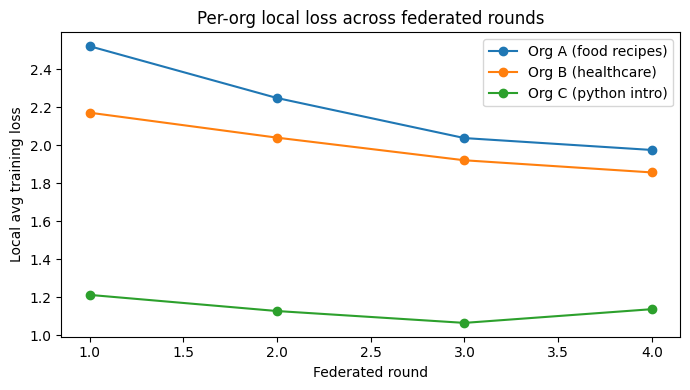

In [24]:
import matplotlib.pyplot as plt

def flatten_phase_losses(phase_history):
    # phase_history: list of rounds, each round is a list of per-client avg losses
    per_client = list(zip(*phase_history)) if phase_history else []
    return per_client

fig, ax = plt.subplots(figsize=(7, 4))
all_rounds_losses = history["phase1"] + history["phase2"]
client_names = [c.name for c in clients]
for i, name in enumerate(client_names):
    ys = [round_losses[i] for round_losses in all_rounds_losses]
    ax.plot(range(1, len(ys) + 1), ys, marker="o", label=name)
ax.set_xlabel("Federated round")
ax.set_ylabel("Local avg training loss")
ax.set_title("Per-org local loss across federated rounds")
ax.legend()
plt.tight_layout()
plt.show()


## 11. Personalization: Global Model v2 + local fine-tune = Personalized Model

Each org takes the shared **Global Model v2** LoRA weights and fine-tunes its *own copy*
further on its own data only, with no aggregation step afterward. The result is a
per-org "personalized" adapter: it benefits from everything learned across all 3 orgs
during federated training, plus an extra local specialization pass.


In [25]:
personalized_states = {}

for client in clients:
    set_peft_model_state_dict(global_model, global_v2_state)
    personalized_state, avg_loss = client.local_train(global_model, CFG, round_tag=" personalize")
    personalized_states[client.name] = {k: v.clone() for k, v in personalized_state.items()}

    safe_name = client.name.split("(")[0].strip().replace(" ", "_")
    save_dir = os.path.join(CFG.output_dir, f"personalized_{safe_name}")
    os.makedirs(save_dir, exist_ok=True)
    set_peft_model_state_dict(global_model, personalized_state)
    global_model.save_pretrained(save_dir)
    print(f"Saved personalized adapter for {client.name} -> {save_dir}")


  [Org A (food recipes) personalize] steps=60 avg_loss=1.9398
Saved personalized adapter for Org A (food recipes) -> ./fl_outputs/personalized_Org_A
  [Org B (healthcare) personalize] steps=60 avg_loss=1.8059
Saved personalized adapter for Org B (healthcare) -> ./fl_outputs/personalized_Org_B
  [Org C (python intro) personalize] steps=60 avg_loss=1.0839
Saved personalized adapter for Org C (python intro) -> ./fl_outputs/personalized_Org_C


## 12. Quick qualitative check: generate sample outputs per org

Loads each org's personalized adapter and generates a short completion for a domain-relevant
prompt, so you can sanity-check that fine-tuning actually nudged the model toward each org's
domain (recipes / health Q&A / python code).


In [26]:
@torch.no_grad()
def generate(model, tokenizer, prompt_instruction, input_text=None, max_new_tokens=120):
    model.eval()
    prompt = build_prompt(prompt_instruction, "", input_text).rsplit("### Response:", 1)[0] + "### Response:\n"
    enc = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **enc,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
    )
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text[len(tokenizer.decode(enc['input_ids'][0], skip_special_tokens=True)):].strip()


sample_prompts = {
    "Org A (food recipes)": "Give me a recipe for a quick vegetable stir fry.",
    "Org B (healthcare)": "What are common symptoms of seasonal allergies?",
    "Org C (python intro)": "Write a python function that checks if a number is prime.",
}

for client in clients:
    set_peft_model_state_dict(global_model, personalized_states[client.name])
    prompt = sample_prompts[client.name]
    completion = generate(global_model, tokenizer, prompt)
    print(f"--- {client.name} ---")
    print("Prompt:", prompt)
    print("Completion:", completion[:400])
    print()


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


--- Org A (food recipes) ---
Prompt: Give me a recipe for a quick vegetable stir fry.
Completion: Chop the onions, celery, carrot and garlic., Heat a teaspoon of oil in a wok or non-stick pan, add the onion and celery and saute for 3 minutes, add the carrot and garlic and saute for a further minute, add the beans and stir well., Add the rice and stir well., Add the chicken and stir well., Add the soy sauce and stir well., Add the water and stir well., Add the broccoli and stir well., Cover and

--- Org B (healthcare) ---
Prompt: What are common symptoms of seasonal allergies?
Completion: What are common symptoms of seasonal allergies? The following are common symptoms of seasonal allergies: watery eyes, itchy eyes, red eyes, runny nose, nasal congestion, sneezing, coughing, hoarseness, sore throat, dry mouth, dry nose, sinus pain or pressure, cough with mucus, cough with blood, sore throat, difficulty breathing, chest pain, wheezing, asthma, rash, hives, itching, skin redness, hai

---

## 13. Notes, caveats, and how to extend this

**What's simplified for this demo (and how to upgrade it for production use):**

- **Single-process simulation, not real multi-machine FL.** All 3 "clients" run in the same
  Python process/GPU here, taking turns. For real cross-organization federated learning where
  each org's data physically never leaves their own infrastructure, port the `OrgClient.local_train`
  logic into [Flower](https://flower.ai)'s `NumPyClient`/`Client` API (already `pip install`ed above) and run
  `flwr` server + per-org clients as separate processes/machines. The FedAvg math here is the
  same math Flower's built-in `FedAvg` strategy uses — you'd mostly be moving the existing
  `local_train` / `fedavg` functions into Flower's client/strategy callback hooks.
- **Loss-masking for labels.** This demo trains on the full prompt+response sequence. For
  better sample efficiency, mask out the prompt tokens in `labels` (set them to `-100`) so the
  model is only scored on the response span — `trl`'s `DataCollatorForCompletionOnlyLM` (already
  installed) does this automatically.
- **LoRA rank 3 is very low capacity** for a 2B model — useful for fast experimentation, but
  expect limited quality. Increasing `CFG.lora_r` to 8–16 is the single highest-leverage change
  for output quality, with a small increase in communicated adapter size.
- **Differential privacy / secure aggregation** are not implemented here. A real
  cross-organization deployment (especially with healthcare data) would typically add per-client
  gradient clipping + noise (DP-SGD) and/or secure aggregation so the central server can't
  reverse-engineer any single org's data from their submitted LoRA weights.
- **Dataset sizes/steps are small** (`samples_per_org`, `max_steps_per_round`) purely so the
  whole pipeline finishes quickly as a demo. Scale these up for a real experiment.
- **Non-IID data across orgs is the realistic case here** — recipes, medical Q&A, and Python
  code are about as different as 3 "clients" can get, which is a good stress test of FedAvg
  (in practice this kind of heterogeneity is exactly why personalization, Section 11, matters).
